# 

In [124]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split


tensor([[-7.5376,  1.3896],
        [-6.9180, -5.6189],
        [-3.4794,  8.4121],
        [-0.7619,  7.0458],
        [-8.1316,  0.5798],
        [-6.5733, -5.2722],
        [-6.9296, -7.6546],
        [ 0.3367,  2.0663],
        [-1.1547,  9.0054],
        [-6.2090,  7.9015]]) tensor([0., 1., 2., 2., 0., 1., 1., 3., 2., 2.])


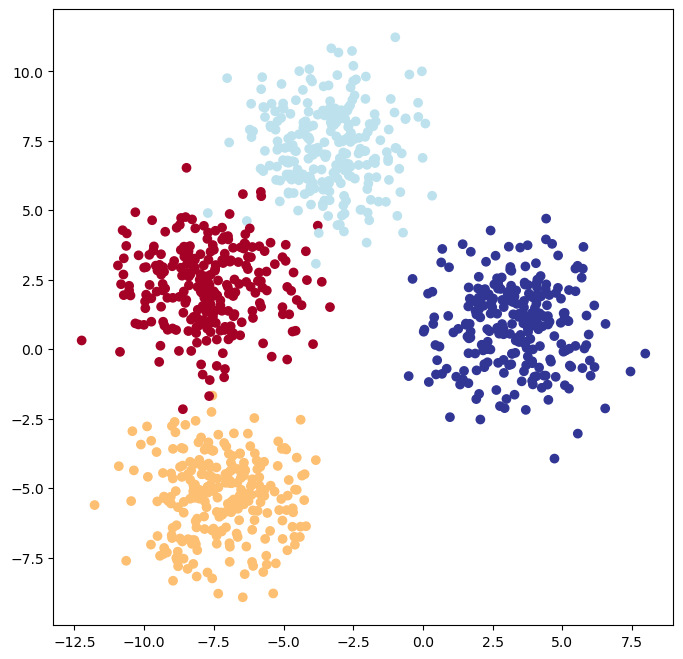

In [125]:
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED  = 43

#create multi class data 
X_blob, y_blob = make_blobs(n_samples =1000,
                            n_features = NUM_FEATURES,
                            centers= NUM_CLASSES,
                            cluster_std= 1.5,
                            random_state = RANDOM_SEED
                           )
#Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.float)

print(X_blob[:10], y_blob[:10])


X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(
    X_blob,
    y_blob,
    test_size = 0.2,
    random_state =RANDOM_SEED
    
)

plt.figure(figsize=(8,8))
plt.scatter(X_blob[:,0],X_blob[:,1],c=y_blob, cmap=plt.cm.RdYlBu)

In [126]:
X_blob_train.shape, X_blob_test.shape, y_blob_train.shape, y_blob_test.shape

(torch.Size([800, 2]),
 torch.Size([200, 2]),
 torch.Size([800]),
 torch.Size([200]))

In [127]:
device= "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [128]:
from torch import nn

class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units = 8):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features= hidden_units),
            nn.Linear(in_features = hidden_units, out_features = hidden_units),
            nn.Linear(in_features = hidden_units, out_features = output_features)
        )

    def forward(self, x):
        return self.linear_layer_stack(x)


model_0 = BlobModel(input_features = NUM_FEATURES,
                    output_features = NUM_CLASSES,
                    hidden_units  = 8).to(device)
model_0

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [129]:
# for param in model_0.parameters():
#     print(param)

In [130]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_0.parameters(),
                            lr=0.1)

In [131]:
model_0(X_blob_train.to(device))[:5]

tensor([[ 2.0375, -0.7974,  2.1523,  2.0318],
        [ 0.6505, -1.2459,  0.5585,  1.2693],
        [ 2.4086, -0.5903,  2.5914,  2.1703],
        [ 0.7074, -1.2987,  0.6136,  1.3542],
        [ 2.3516, -0.5947,  2.5279,  2.1283]], grad_fn=<SliceBackward0>)

In [132]:
model_0(X_blob_train.to(device))[0].shape, NUM_CLASSES

(torch.Size([4]), 4)

In [133]:
y_logits = model_0(X_blob_test.to(device))

y_pred_probs = torch.softmax(y_logits, dim =1)

print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[ 2.5502,  0.1743,  2.8578,  1.7067],
        [ 2.0097, -0.1570,  2.2141,  1.5274],
        [ 1.0600, -1.0961,  1.0316,  1.4814],
        [-1.0511, -0.1913, -1.1654, -0.8749],
        [-0.3103, -1.3683, -0.5185,  0.5993]], grad_fn=<SliceBackward0>)
tensor([[0.3468, 0.0322, 0.4717, 0.1492],
        [0.3380, 0.0387, 0.4146, 0.2087],
        [0.2769, 0.0321, 0.2691, 0.4220],
        [0.1836, 0.4337, 0.1638, 0.2190],
        [0.2154, 0.0748, 0.1749, 0.5349]], grad_fn=<SliceBackward0>)


In [134]:
torch.sum(y_pred_probs[0])

tensor(1., grad_fn=<SumBackward0>)

In [135]:
print(y_pred_probs[0])
print(torch.argmax(y_pred_probs[0]))

tensor([0.3468, 0.0322, 0.4717, 0.1492], grad_fn=<SelectBackward0>)
tensor(2)


In [136]:
print(f"type is {y_logits.type, y_blob_train.type}")
print(y_logits[0], y_blob_train[0])
print(f"shape is {y_logits.shape, y_blob_train.shape}")
###y_blob_train must be long
y_blob_train = y_blob_train.long()
print(y_logits[0], y_blob_train[0])

type is (<built-in method type of Tensor object at 0x00000224FDB2EE80>, <built-in method type of Tensor object at 0x00000224F9B2D8F0>)
tensor([2.5502, 0.1743, 2.8578, 1.7067], grad_fn=<SelectBackward0>) tensor(0.)
shape is (torch.Size([200, 4]), torch.Size([800]))
tensor([2.5502, 0.1743, 2.8578, 1.7067], grad_fn=<SelectBackward0>) tensor(0)


In [137]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [144]:
torch.manual_seed(42)
epochs = 50

for epoch in range(epochs):
    model_0.train()

    y_logits = model_0(X_blob_train)

    y_pred = torch.softmax(y_logits, dim=1).argmax(dim = 1)

    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_true=y_blob_train,
                      y_pred = y_pred)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(X_blob_test)
        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
        y_blob_test = y_blob_test.long()
        test_loss =  loss_fn(test_logits, y_blob_test)
        test_acc = accuracy_fn(y_pred = test_pred,
                               y_true = y_blob_test)

    if epoch % 5 == 0:
        print(f" Epoch : {epoch} | Loss : {loss:.5f} , Acc : {acc:.2f}% | test loss :{test_loss:.5f}, test acc : {test_acc:.2f}%")


 Epoch : 0 | Loss : 0.23562 , Acc : 97.88% | test loss :0.20366, test acc : 99.00%
 Epoch : 5 | Loss : 0.15946 , Acc : 98.12% | test loss :0.13643, test acc : 99.00%
 Epoch : 10 | Loss : 0.12218 , Acc : 98.25% | test loss :0.10221, test acc : 99.50%
 Epoch : 15 | Loss : 0.10081 , Acc : 98.38% | test loss :0.08205, test acc : 99.50%
 Epoch : 20 | Loss : 0.08720 , Acc : 98.50% | test loss :0.06893, test acc : 99.50%
 Epoch : 25 | Loss : 0.07785 , Acc : 98.50% | test loss :0.05977, test acc : 99.50%
 Epoch : 30 | Loss : 0.07108 , Acc : 98.50% | test loss :0.05304, test acc : 100.00%
 Epoch : 35 | Loss : 0.06597 , Acc : 98.50% | test loss :0.04788, test acc : 100.00%
 Epoch : 40 | Loss : 0.06198 , Acc : 98.50% | test loss :0.04381, test acc : 100.00%
 Epoch : 45 | Loss : 0.05878 , Acc : 98.62% | test loss :0.04052, test acc : 100.00%


In [142]:
print(y_pred[:10], y_blob_train[:10])

tensor([0, 2, 0, 2, 0, 3, 1, 1, 3, 3]) tensor([0, 2, 0, 2, 0, 3, 1, 1, 3, 3])


In [143]:
print(test_pred[:10], y_blob_test[:10])

tensor([1, 0, 2, 3, 2, 2, 2, 2, 0, 2]) tensor([1, 0, 2, 3, 2, 2, 2, 2, 0, 2])


In [146]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


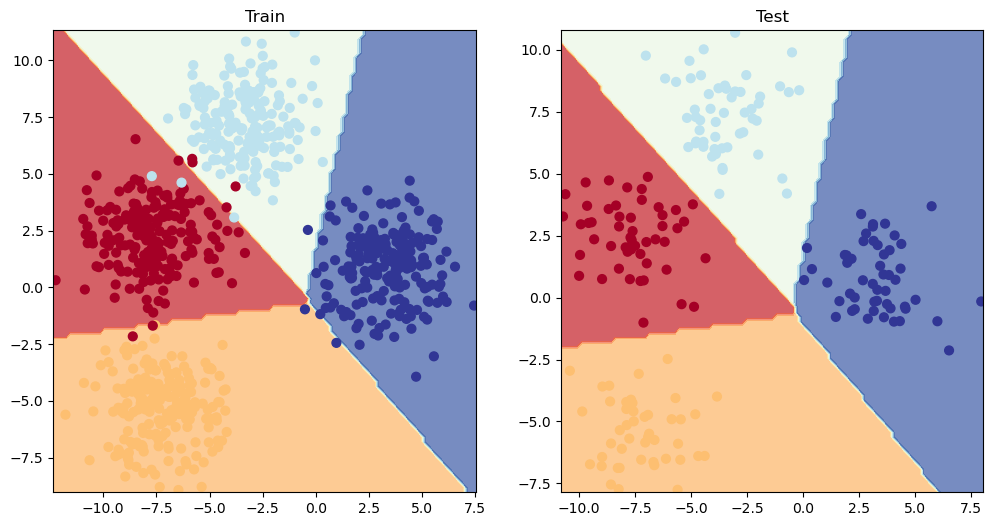

In [148]:
plt.figure(figsize = (12, 6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_blob_train, y_blob_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_blob_test, y_blob_test)